In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

#Loading product data, keep only relevant columns
product_df = pd.read_csv("product_info.csv")
product_df = product_df[["product_id", "product_name", "loves_count", "rating", "reviews", "ingredients", "price_usd", "highlights", "primary_category", "secondary_category", "tertiary_category"]]

# easier way to get the dataset
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

product_df.info()
product_df.head()

Using Colab cache for faster access to the 'sephora-products-and-skincare-reviews' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   loves_count         8494 non-null   int64  
 3   rating              8216 non-null   float64
 4   reviews             8216 non-null   float64
 5   ingredients         7549 non-null   object 
 6   price_usd           8494 non-null   float64
 7   highlights          6287 non-null   object 
 8   primary_category    8494 non-null   object 
 9   secondary_category  8486 non-null   object 
 10  tertiary_category   7504 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 730.1+ KB


,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category
0,P473671,Fragrance Discovery Set,6320,3.6364,11.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets
1,P473668,La Habana Eau de Parfum,3827,4.1538,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
2,P473662,Rainbow Bar Eau de Parfum,3253,4.2500,16.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
3,P473660,Kasbah Eau de Parfum,3018,4.4762,21.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
4,P473658,Purple Haze Eau de Parfum,2691,3.2308,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Loading and concatenating all reviews datasets, keep only relevant columns
reviews1 = pd.read_csv(f"{path}/reviews_0-250.csv")
reviews2 = pd.read_csv(f"{path}/reviews_250-500.csv")
reviews3 = pd.read_csv(f"{path}/reviews_500-750.csv")
reviews4 = pd.read_csv(f"{path}/reviews_750-1250.csv")
reviews5 = pd.read_csv(f"{path}/reviews_1250-end.csv")

reviews_df = pd.concat(
    [reviews1, reviews2, reviews3, reviews4, reviews5],
    ignore_index=True
)

reviews_df = reviews_df.drop_duplicates()
reviews_df = reviews_df[["product_id", "product_name", "rating", "is_recommended", "total_feedback_count", "total_pos_feedback_count", "review_text"]]

reviews_df.info()
reviews_df.head()

/tmp/ipython-input-3583489310.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews1 = pd.read_csv(f"{path}/reviews_0-250.csv")
/tmp/ipython-input-3583489310.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews4 = pd.read_csv(f"{path}/reviews_750-1250.csv")
/tmp/ipython-input-3583489310.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews5 = pd.read_csv(f"{path}/reviews_1250-end.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 7 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   product_id                1094411 non-null  object 
 1   product_name              1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_pos_feedback_count  1094411 non-null  int64  
 6   review_text               1092967 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 58.4+ MB


,product_id,product_name,rating,is_recommended,total_feedback_count,total_pos_feedback_count,review_text
0,P504322,Gentle Hydra-Gel Face Cleanser,5,1.0,2,2,I use this with the Nudestix “Citrus Clean Bal...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,1,0.0,0,0,I bought this lip mask after reading the revie...
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,My review title says it all! I get so excited ...
3,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,I’ve always loved this formula for a long time...
4,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,"If you have dry cracked lips, this is a must h..."


In [4]:
#Filter for only skincare in products dataset
product_df = product_df[
    product_df["primary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["secondary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["tertiary_category"].str.contains("Skincare", case=False, na=False)
]

reviews_df = reviews_df[reviews_df['product_id'].isin(product_df['product_id'])]
print(product_df.shape)
print(reviews_df.shape)

reviews_df['product_id'].value_counts()

(2522, 11)
(1094411, 7)


,count
product_id,
P420652,16138
P7880,8736
P218700,7763
P248407,7547
P269122,7414
...,...
P480441,1
P469829,1
P505174,1


In [5]:
#Check for null values
print(product_df.isna().sum())
print(reviews_df.isna().sum())

product_id              0
product_name            0
loves_count             0
rating                 73
reviews                73
ingredients           143
price_usd               0
highlights            448
primary_category        0
secondary_category      0
tertiary_category     446
dtype: int64
product_id                       0
product_name                     0
rating                           0
is_recommended              167988
total_feedback_count             0
total_pos_feedback_count         0
review_text                   1444
dtype: int64


In [6]:
#Drop null rows that may affect analysis
product_df = product_df[product_df["rating"].notna()]
product_df = product_df[product_df["ingredients"].notna()]

reviews_df = reviews_df[reviews_df["is_recommended"].notna()]

In [7]:
print("Products:", product_df.shape)
print("Unique Products:", product_df["product_id"].nunique())

print("Reviews:", reviews_df.shape)
print("Unique Reviewed Products:", reviews_df["product_id"].nunique())

Products: (2313, 11)
Unique Products: 2313
Reviews: (926423, 7)
Unique Reviewed Products: 2351


In [8]:
#Remove mini size products
product_df = product_df[~(
        product_df["primary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["secondary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["tertiary_category"].str.contains("Mini Size", case=False, na=False)
    )
]

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [9]:
#Clean price data, create price bands
product_df = product_df[(product_df["price_usd"].notna()) & (product_df["price_usd"] > 0)]
product_df["price_band"] = pd.cut(
    product_df["price_usd"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0–20", "20–40", "40–60", "60–80", "80+"]
)

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [10]:
#Aggregate reviews to product level
review_agg = reviews_df.groupby("product_id").agg(
    total_reviews=("rating", "count"),
    recommend_rate=("is_recommended", "mean"),
    total_positive=("total_pos_feedback_count", "sum"),
    total_feedback=("total_feedback_count", "sum")
).reset_index()

review_agg["positive_feedback_ratio"] = (review_agg["total_positive"] / review_agg["total_feedback"])

In [11]:
#Merge aggregated reviews with products, drop products with no reviews
final_df = product_df.merge(review_agg, on="product_id", how="left")
final_df = final_df[final_df["total_reviews"].notna()]

final_df.shape

(2117, 17)

In [12]:
#Determining a minimum review threshold by looking at distribution (how many reviews products have on avg)
final_df["total_reviews"].describe()
final_df["total_reviews"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

for n in [1, 5, 10, 15, 20, 35]:
    count = (final_df["total_reviews"] < n).sum()
    print(f"Products with < {n} reviews: {count}")

Products with < 1 reviews: 0
Products with < 5 reviews: 118
Products with < 10 reviews: 209
Products with < 15 reviews: 303
Products with < 20 reviews: 382
Products with < 35 reviews: 529


In [13]:
#Setting minimum review threshold at 10
final_df = final_df[final_df["total_reviews"] >= 10]

print("Final dataset shape:", final_df.shape)
print("Unique products:", final_df["product_id"].nunique())

Final dataset shape: (1908, 17)
Unique products: 1908


In [14]:
final_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_band,total_reviews,recommend_rate,total_positive,total_feedback,positive_feedback_ratio
0,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,80+,1321.0,0.920515,2798.0,3467.0,0.807038
1,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,80+,1126.0,0.762877,8131.0,10025.0,0.811072
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,60–80,1142.0,0.938704,1330.0,1730.0,0.768786
3,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,20–40,649.0,0.713405,4527.0,5413.0,0.836320
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,20–40,232.0,0.814655,698.0,803.0,0.869240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,P416923,Superfood Hydrate + Firm Peptide Eye Cream,38812,3.6564,326.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",38.0,"['Hyaluronic Acid', 'Good for: Loss of firmnes...",Skincare,Eye Care,Eye Creams & Treatments,20–40,287.0,0.609756,1547.0,1964.0,0.787678
2144,P482329,Retinal + Niacinamide Youth Serum,41445,4.5841,315.0,"['Water/Aqua/Eau, Butylene Glycol, Triethylhex...",69.0,"['Good for: Dullness/Uneven Texture', 'Clean +...",Skincare,Treatments,Face Serums,60–80,317.0,0.940063,680.0,1066.0,0.637899
2145,P502479,Kombucha + 10% AHA Liquid Exfoliant with Lacti...,11299,4.5926,81.0,"['Water/Aqua/Eau, Pentylene Glycol, Lactic Aci...",42.0,"['Good for: Dullness/Uneven Texture', 'Lactic ...",Skincare,Cleansers,Exfoliators,40–60,82.0,0.926829,130.0,170.0,0.764706
2146,P473336,The Youth System,53522,4.5526,76.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",59.0,"['Vegan', 'Vitamin C', 'Good for: Pores', 'Cle...",Skincare,Value & Gift Sets,NaN,40–60,77.0,0.896104,522.0,714.0,0.731092


In [15]:
final_df.to_csv("cleaned_dataset.csv", index=False)

In [50]:
# group to product level
product_df = final_df.groupby('product_id').agg(
    price_usd=('price_usd', 'first'),     # taking the price
    recommendation_rate=('recommend_rate', 'mean'),     # calculate average recommendation
    total_reviews=('total_reviews', 'first'),      # Use 'first' to get the already calculated total reviews
    rating=('rating', 'mean') # Include rating in the aggregation
).reset_index()

In [36]:
print("Total reviews per product:")
display(final_df[['product_id', 'product_name', 'total_reviews']].head())

print("\nSummary statistics for total reviews:")
display(final_df['total_reviews'].describe())

Total reviews per product:


,product_id,product_name,total_reviews
0,P439055,GENIUS Sleeping Collagen Moisturizer,1321.0
1,P421277,GENIUS Liquid Collagen Serum,1126.0
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,1142.0
3,P432045,GENIUS Liquid Collagen Lip Treatment,649.0
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,232.0



Summary statistics for total reviews:


,total_reviews
count,1908.000000
mean,437.773585
std,779.011648
min,10.000000
25%,55.000000
50%,186.000000
75%,485.000000
max,15899.000000


In [37]:
products_over_100 = final_df[final_df['total_reviews'] > 100]
print(f"Number of products with more than 100 reviews: {len(products_over_100)}")

Number of products with more than 100 reviews: 1217


In [51]:
product_df = product_df[product_df['total_reviews'] > 100]

# looking to see which products have 50+ reviews -- but this can be changed at any point

In [52]:
product_df['price_band'] = pd.qcut(
    product_df['price_usd'],
    3,
    labels=['Low', 'Medium', 'High']
)

price_summary = product_df.groupby('price_band', observed=True)['recommendation_rate'].agg(
    ['mean', 'std', 'count']
)

print(price_summary)

                mean       std  count
price_band                           
Low         0.822391  0.097465    430
Medium      0.855533  0.093509    401
High        0.865456  0.087365    386


This shows us that a higher price means a higher recommendation. It seems that the 'high' price band had the highest average recommendation rate of ~86.5%, while 'medium' had ~85.5%, and 'low' with ~82.2%.

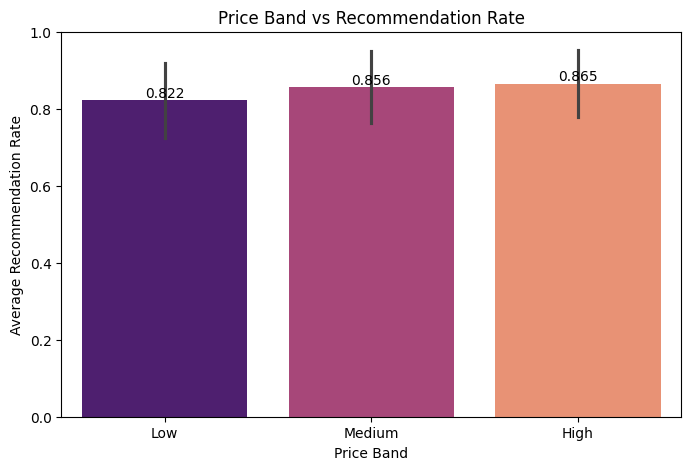

In [58]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=product_df,
    x='price_band',
    y='recommendation_rate',
    errorbar='sd',           # show standard deviation as error bars
    palette='magma',
    hue='price_band',        # Assign x variable to hue to resolve the FutureWarning
    legend=False             # Set legend to False as suggested by the FutureWarning
)
plt.title('Price Band vs Recommendation Rate')
plt.xlabel('Price Band')
plt.ylabel('Average Recommendation Rate')
plt.ylim(0,1)         # since recommendation rate is 0-1

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Use 3 decimal places for recommendation rate

plt.show()

In [53]:
# Analyze average rating by price band
rating_summary = product_df.groupby('price_band', observed=True)['rating'].agg(
    ['mean', 'std', 'count']
)

print("Average Rating by Price Band:")
print(rating_summary)

Average Rating by Price Band:
                mean       std  count
price_band                           
Low         4.236932  0.344842    430
Medium      4.354499  0.299662    401
High        4.377753  0.288946    386


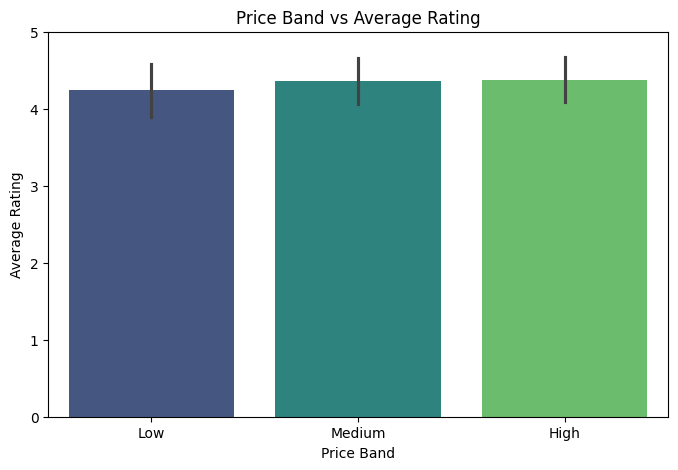

In [56]:
# Visualize average rating by price band
plt.figure(figsize=(8,5))
sns.barplot(
    data=product_df,
    x='price_band',
    y='rating',
    errorbar='sd',           # show standard deviation as error bars
    palette='viridis',
    hue='price_band',        # Assign x variable to hue for clarity
    legend=False             # Set legend to False
)
plt.title('Price Band vs Average Rating')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(0, 5)         # Ratings are typically on a 1-5 scale

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

Created both tables on Recommendation Rate and Average Rating. Now, we're showing the distribution regarding the Average Ratings for both

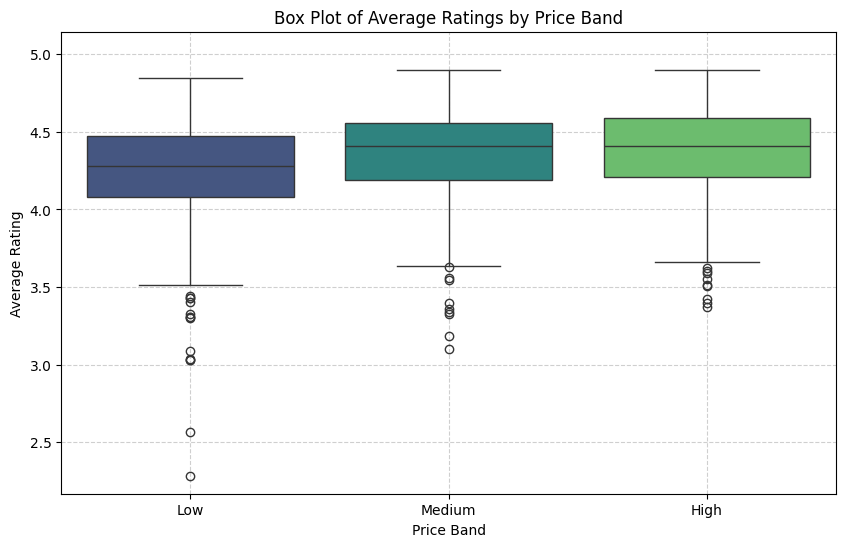

In [65]:
# Visualize the distribution of average ratings across price bands using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=product_df,
    x='price_band',
    y='rating',
    palette='viridis',
    hue='price_band', # Assign x variable to hue for clarity
    legend=False      # Set legend to False
)
plt.title('Box Plot of Average Ratings by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(product_df['rating'].min() * 0.95, product_df['rating'].max() * 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [60]:
# Calculate the Pearson correlation coefficient
correlation = product_df['rating'].corr(product_df['recommendation_rate'])
print(f"Pearson Correlation between Average Rating and Recommendation Rate: {correlation:.4f}")

Pearson Correlation between Average Rating and Recommendation Rate: 0.9569


## Summary of Findings

*   **Higher Price = Higher Satisfaction:** Both average customer ratings and recommendation rates show a clear positive trend. Skincare products in the 'High' price band consistently have better ratings and are recommended more often than those in 'Medium' and 'Low' price bands.

    *   **Recommendation Rate:**
        *   Low Price: ~82.2%
        *   Medium Price: ~85.5%
        *   High Price: ~86.5%

    *   **Average Rating (out of 5):**
        *   Low Price: ~4.24
        *   Medium Price: ~4.35
        *   High Price: ~4.38

*   **Strong Correlation:** There is an extremely strong positive correlation (Pearson Correlation Coefficient: **0.9569**) between a product's average rating and its recommendation rate. This means products that customers rate highly are almost always highly recommended.

*   **Distribution Insights:**
    *   Box plots and violin plots visually confirm that higher-priced products tend to have their ratings clustered at the higher end of the scale.
    *   The variability in ratings within each price band is relatively similar.

*   **Analysis:** Our findings are based on products with over 100 reviews, ensuring that the conclusions are drawn from substantial customer feedback.

In [67]:
product_df['normalized_rating'] = product_df['rating'] / 5.0
product_df['combined_satisfaction'] = (product_df['normalized_rating'] + product_df['recommendation_rate']) / 2

print(product_df[['rating', 'normalized_rating', 'recommendation_rate', 'combined_satisfaction']].head())

   rating  normalized_rating  recommendation_rate  combined_satisfaction
1  4.4199            0.88398             0.871314               0.877647
2  4.4431            0.88862             0.871795               0.880207
5  4.6122            0.92244             0.821012               0.871726
7  4.4933            0.89866             0.753731               0.826196
9  4.0722            0.81444             0.756906               0.785673


In [69]:
combined_satisfaction_summary = product_df.groupby('price_band', observed=True)['combined_satisfaction'].agg(
    ['mean', 'std', 'count']
)

print("Combined Satisfaction Summary by Price Band:")
print(combined_satisfaction_summary)

Combined Satisfaction Summary by Price Band:
                mean       std  count
price_band                           
Low         0.834889  0.082419    430
Medium      0.863216  0.075972    401
High        0.870503  0.071630    386


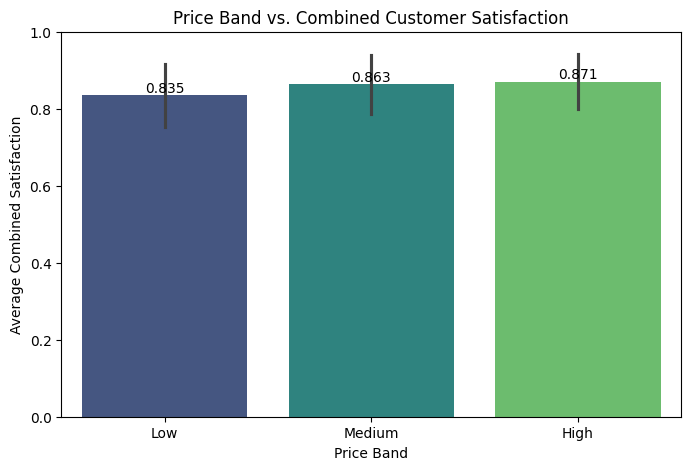

In [72]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=product_df,
    x='price_band',
    y='combined_satisfaction',
    errorbar='sd',
    palette='viridis',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs. Combined Customer Satisfaction')
plt.xlabel('Price Band')
plt.ylabel('Average Combined Satisfaction')
plt.ylim(0,1)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.show()